# Cardio HSIC results: the symbolic mechanism for systolic pressure

Reads the artefacts written by `cardio_hsic.ipynb` -- it does **not** retrain anything.
Run the training notebook first.

Companion to `cardio_hsic_results.ipynb`, which studies `P(ischemia)`. That target is a
**discrete** node, so `kan_model_mixed` trains it with cross-entropy, no residual is formed,
the HSIC term of the hybrid loss is never evaluated, and `sweep_beta_weight` hard-sets its
beta to 0. The beta=0 and optimal-beta ischemia mechanisms therefore come out identical and
the comparison has nothing to show.

`systolic` is the node where beta actually bites:

- it is **continuous**, so the hybrid loss `alpha * MSE / var + beta * HSIC(x, residual)`
  really is what gets minimised;
- the beta sweep selects a non-zero value for it;
- it is the node the whole experiment's headline metric is computed on --
  `HSIC(residuals[systolic], eval[[age, bmi]])` in `utils/cardio.py`.

Because the target is continuous the formula is **not** a logit: it is `E[systolic | age, bmi]`
directly, in the z-scored units the model was trained on. Plots denormalise it to mmHg with
`node_info[systolic]`. A KAAM is additive in its inputs, so that expectation splits into one
term per parent plus a constant -- the decomposition every panel below is built from.

> **Sample size.** The stored artefacts come from a small evaluation set (`cardio_hsic.ipynb`
> currently subsamples). The cell below prints the actual shape. At this N the curves are
> illustrative of *how the mechanisms differ*, not publication-ready estimates -- rerun the
> training notebook at full size before these figures go in the paper.

In [19]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import display

from datasets.cardio import get_cardio_graph
from plotting.cardio_formula import get_delta
from utils.paths import get_experiment_paths


# Point this at another tree only if the training notebook wrote somewhere else.
OUTPUT_DIR = None
paths = get_experiment_paths('cardio', output_dir=OUTPUT_DIR)
data_dir, samples_dir = str(paths.data), str(paths.samples)

graph_cardio = get_cardio_graph()
factual_eval_d = pd.read_csv(os.path.join(data_dir, 'cardio_factual_eval_d.csv'))
with open(os.path.join(data_dir, 'cardio_node_info.pkl'), 'rb') as f:
    node_info = pickle.load(f)
with open(os.path.join(data_dir, 'best_beta_kaam_mixed_cardio.pkl'), 'rb') as f:
    best_beta = pickle.load(f)

TARGET = 'systolic'
# Same ordering kan_model_mixed uses for a node's inputs, so formula symbols x_1..x_n line up.
x_cols = list(graph_cardio.predecessors(TARGET))
TARGET_MEAN = float(node_info[TARGET]['mean'])
TARGET_STD = float(node_info[TARGET]['std'])
BETA_OPT = float(best_beta[TARGET])

print(f'Evaluation set : {factual_eval_d.shape}')
print(f'Target         : {TARGET} ({node_info[TARGET]["type"]}, mean {TARGET_MEAN:.1f} mmHg, std {TARGET_STD:.2f})')
print(f'Parents        : {x_cols}')
print(f'Parent types   : { {c: node_info[c]["type"] for c in x_cols} }')
print()
print('beta selected per node by the sweep (KAAM):')
for node, beta in best_beta.items():
    if node == TARGET:
        tag = '  <- our target'
    elif node_info[node]['type'] == 'discrete':
        tag = '  (discrete: beta is inert)'
    else:
        tag = ''
    print(f'  {node:<10s} {beta:>4g}{tag}')

assert BETA_OPT > 0, f'beta selected for {TARGET} is 0 - there is no optimal-vs-zero contrast to study'

Evaluation set : (2208, 6)
Target         : systolic (continuous, mean 133.2 mmHg, std 22.22)
Parents        : ['age', 'bmi']
Parent types   : {'age': 'continuous', 'bmi': 'continuous'}

beta selected per node by the sweep (KAAM):
  diabetes      0  (discrete: beta is inert)
  systolic    0.1  <- our target
  ischemia      0  (discrete: beta is inert)
  bmi         0.1
  macv          0  (discrete: beta is inert)


## The symbolic mechanism for systolic

Both models are the same `kaam_mixed_symbolic` pipeline; the only difference is the loss the
KAN was trained under. `cardio_formulas_kaam.pkl` holds the run with the beta chosen by the
sweep, `cardio_formulas_kaam_beta0.pkl` the reference with beta pinned to 0 for every node
(pure MSE, the option the sweep excludes from selection).

In [20]:
with open(os.path.join(samples_dir, 'cardio_formulas_kaam.pkl'), 'rb') as f:
    formulae = pickle.load(f)
with open(os.path.join(samples_dir, 'cardio_formulas_kaam_beta0.pkl'), 'rb') as f:
    formulae_beta0 = pickle.load(f)


def decompose(raw_formula):
    """Split a KAAM mechanism into per-parent contributions plus a constant."""
    # get_delta renames the generic x_1..x_n symbols to the actual parent names.
    expr, frames = get_delta(factual_eval_d[x_cols], raw_formula)
    frame = frames[0]
    constant = float(frame['const'].iloc[0])
    used_vars = sorted((str(s) for s in expr.free_symbols), key=x_cols.index)
    # get_delta only emits columns for parents that survive pruning; reinstate the rest as
    # zeros so every parent has a (possibly flat) contribution to plot.
    terms = frame.drop(columns='const').reindex(columns=x_cols, fill_value=0.0)
    return expr, terms, constant, used_vars


formula, delta_terms, const, used = decompose(formulae[TARGET])
formula_beta0, delta_terms_beta0, const_beta0, used_beta0 = decompose(formulae_beta0[TARGET])

LABEL_OPT = f'beta={BETA_OPT:g} (optimal)'
MODELS = [
    (LABEL_OPT, formula, delta_terms, const, used),
    ('beta=0', formula_beta0, delta_terms_beta0, const_beta0, used_beta0),
]

for label, expr, _terms, constant, used_vars in MODELS:
    dropped = [c for c in x_cols if c not in used_vars]
    print(f'--- {label} ---')
    print(f'  systolic (z units) = {sp.expand(expr)}')
    # Only the target is denormalised here; the parents stay z-scored, as the model saw them.
    print(f'  systolic (mmHg)    = {sp.expand(expr * TARGET_STD + TARGET_MEAN)}')
    print(f'  parents in formula : {used_vars}')
    print(f'  pruned away        : {dropped if dropped else "none"}')
    print(f'  constant           : {constant:.4f} (z units)')
    print()

# The additive split must reproduce each formula exactly, on however many patients we have.
for label, expr, terms, constant, used_vars in MODELS:
    check = terms.sum(axis=1) + constant
    direct = np.array([
        float(expr.subs({sp.symbols(c): factual_eval_d[c].iloc[i] for c in used_vars}))
        for i in range(len(factual_eval_d))
    ])
    assert np.allclose(check.to_numpy(), direct, atol=1e-6), f'{label}: additive decomposition does not match the formula'
print(f'Additive decomposition verified for both models ({len(factual_eval_d)} patients).')

# Mirror of the coincidence note in the ischemia notebook: here the two must genuinely differ,
# otherwise the rest of the notebook is plotting one curve twice.
difference = sp.expand(formula - formula_beta0)
assert difference != 0, 'the beta=0 and optimal-beta systolic mechanisms are identical - nothing to compare'
print(f'\nbeta=opt minus beta=0 = {difference}')

display(sp.Eq(sp.Symbol('systolic_beta_opt'), sp.expand(formula)))
display(sp.Eq(sp.Symbol('systolic_beta_0'), sp.expand(formula_beta0)))

--- beta=0.1 (optimal) ---
  systolic (z units) = 0.353*age + 0.284*bmi + 0.028
  systolic (mmHg)    = 7.84583095738944*age + 6.31166172972563*bmi + 133.839657104144
  parents in formula : ['age', 'bmi']
  pruned away        : none
  constant           : 0.0280 (z units)

--- beta=0 ---
  systolic (z units) = 0.359*age + 0.284*bmi + 0.028
  systolic (mmHg)    = 7.97876516102432*age + 6.31166172972563*bmi + 133.839657104144
  parents in formula : ['age', 'bmi']
  pruned away        : none
  constant           : 0.0280 (z units)

Additive decomposition verified for both models (2208 patients).

beta=opt minus beta=0 = -0.00598*age


Eq(systolic_beta_opt, 0.353*age + 0.284*bmi + 0.028)

Eq(systolic_beta_0, 0.359*age + 0.284*bmi + 0.028)

## Term-by-term comparison

`symbolic_kan_regressor` fits one closed-form term per (parent, output) activation, so the two
mechanisms can disagree on *which monomials appear at all*, not just on their coefficients.
The table below lines them up: a row non-zero in one column and zero in the other is a term the
HSIC penalty added or removed.

In [21]:
def coefficients(expr):
    """Flatten an expanded additive expression into {monomial string: coefficient}."""
    return {str(monomial): float(coeff) for monomial, coeff in sp.expand(expr).as_coefficients_dict().items()}


coef_opt = coefficients(formula)
coef_b0 = coefficients(formula_beta0)
# Constants come back under the key '1'; sort it last, every monomial alphabetically before it.
monomials = sorted(set(coef_opt) | set(coef_b0), key=lambda m: (m == '1', m))

COL_OPT, COL_B0 = LABEL_OPT, 'beta=0'
coef_table = pd.DataFrame(
    {
        COL_OPT: [coef_opt.get(m, 0.0) for m in monomials],
        COL_B0: [coef_b0.get(m, 0.0) for m in monomials],
    },
    index=['const' if m == '1' else m for m in monomials],
)
coef_table['difference'] = coef_table[COL_OPT] - coef_table[COL_B0]

print('Coefficients of the systolic mechanism (target and parents both in z units):')
print(coef_table.round(4).to_string())

only_opt = [m for m in coef_table.index if coef_table.at[m, COL_B0] == 0.0 and coef_table.at[m, COL_OPT] != 0.0]
only_b0 = [m for m in coef_table.index if coef_table.at[m, COL_OPT] == 0.0 and coef_table.at[m, COL_B0] != 0.0]
print(f'\nTerms only in the optimal-beta model : {only_opt if only_opt else "none"}')
print(f'Terms only in the beta=0 model       : {only_b0 if only_b0 else "none"}')

Coefficients of the systolic mechanism (target and parents both in z units):
       beta=0.1 (optimal)  beta=0  difference
age                 0.353   0.359      -0.006
bmi                 0.284   0.284       0.000
const               0.028   0.028       0.000

Terms only in the optimal-beta model : none
Terms only in the beta=0 model       : none


## Partial dependence of systolic on each parent

For parent `j` swept over its observed range, the other parents are held at their mean
contribution across the evaluation set:

`systolic(x_j = v) = const + sum_{k != j} mean(delta_k) + delta_j(v)`

evaluated in z units, then rescaled to mmHg by `z * std + mean`. Both parents of `systolic`
are continuous, so every panel is a curve. The grey ticks along the bottom mark the observed
values -- the curve is supported by data only where they are dense.

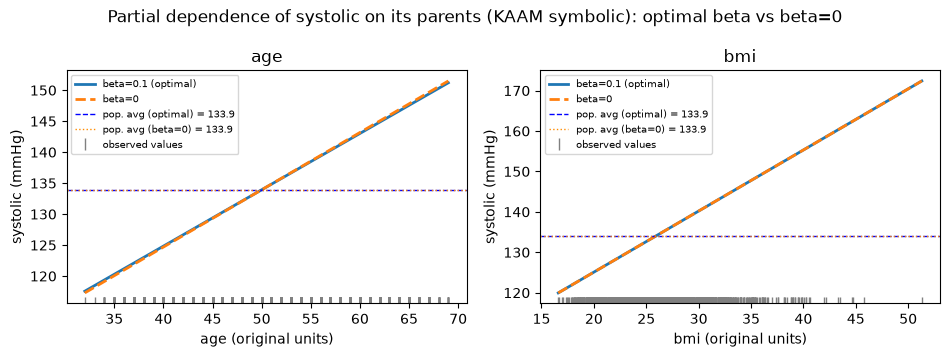

Saved -> C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\cardio\figures\systolic_pdp.pdf


In [22]:
def term_values(var, grid_values, expr, used_vars):
    """Evaluate this parent's additive contribution over a grid, in standardised units."""
    if var not in used_vars:
        return np.zeros_like(grid_values, dtype=float)
    dependent_part = expr.as_independent(sp.symbols(var), as_Add=True)[1]
    single = sp.lambdify(sp.symbols(var), dependent_part, 'numpy')
    return np.asarray(single(grid_values), dtype=float) * np.ones_like(grid_values, dtype=float)


def denorm(var, values):
    if node_info[var]['type'] != 'continuous':
        return values
    return values * node_info[var]['std'] + node_info[var]['mean']


def to_mmhg(z_values):
    """The target is z-scored during training; put predictions back on the clinical scale."""
    return np.asarray(z_values, dtype=float) * TARGET_STD + TARGET_MEAN


mean_delta = delta_terms.mean(axis=0)
baseline = const + mean_delta.sum()

mean_delta_beta0 = delta_terms_beta0.mean(axis=0)
baseline_beta0 = const_beta0 + mean_delta_beta0.sum()

fig, axs = plt.subplots(1, len(x_cols), figsize=(4.8 * len(x_cols), 3.6), squeeze=False)

for i, var in enumerate(x_cols):
    ax = axs[0][i]
    observed = factual_eval_d[var].to_numpy()
    grid = np.linspace(observed.min(), observed.max(), 200)

    # Swap this parent's mean contribution for its value on the grid.
    curve = to_mmhg(baseline - mean_delta[var] + term_values(var, grid, formula, used))
    curve_beta0 = to_mmhg(baseline_beta0 - mean_delta_beta0[var]
                          + term_values(var, grid, formula_beta0, used_beta0))
    x_plot = denorm(var, grid)

    ax.plot(x_plot, curve, color='tab:blue', lw=2, label=LABEL_OPT)
    ax.plot(x_plot, curve_beta0, color='tab:orange', lw=2, ls='--', label='beta=0')
    ax.axhline(to_mmhg(baseline), color='b', ls='--', lw=1,
               label=f'pop. avg (optimal) = {to_mmhg(baseline):.1f}')
    ax.axhline(to_mmhg(baseline_beta0), color='darkorange', ls=':', lw=1,
               label=f'pop. avg (beta=0) = {to_mmhg(baseline_beta0):.1f}')

    y_low, y_high = ax.get_ylim()
    ax.plot(denorm(var, observed), np.full(observed.shape, y_low), '|', color='gray', ms=8,
            label='observed values')
    ax.set_ylim(y_low, y_high)

    ax.set_xlabel(f'{var} (original units)')
    ax.set_ylabel('systolic (mmHg)')
    ax.set_title(var if (var in used and var in used_beta0) else f'{var}  [pruned from one formula]')
    ax.legend(fontsize=7)

fig.suptitle('Partial dependence of systolic on its parents (KAAM symbolic): optimal beta vs beta=0')
fig.tight_layout()
fig.savefig(paths.figures / 'systolic_pdp.pdf', bbox_inches='tight')
plt.show()
print(f"Saved -> {paths.figures / 'systolic_pdp.pdf'}")

## Per-parent contribution

The same decomposition without the partial-dependence framing: each panel is the parent's own
additive term at the observed evaluation points, in mmHg (`delta * std`, no mean offset -- these
are deviations, and they sum with the constant to the prediction). This is the KAAM read
directly, so the gap between the two curves is the difference between the fitted terms.

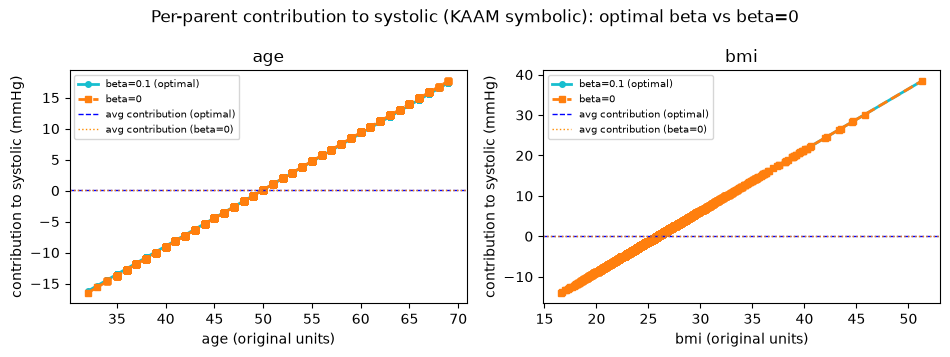

Saved -> C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\cardio\figures\systolic_contributions.pdf

     mean contribution mmHg (beta=0.1 (optimal))  mean contribution mmHg (beta=0)
age                                        0.115                            0.117
bmi                                       -0.043                           -0.043

constant : 0.0280 (optimal) vs 0.0280 (beta=0)   [z units]
baseline : 133.91 mmHg (optimal) vs 133.91 mmHg (beta=0)
observed : 132.76 mmHg mean in the evaluation set


In [23]:
fig, axs = plt.subplots(1, len(x_cols), figsize=(4.8 * len(x_cols), 3.6), squeeze=False)

for i, var in enumerate(x_cols):
    ax = axs[0][i]
    order = np.argsort(factual_eval_d[var].to_numpy())
    x_plot = denorm(var, factual_eval_d[var].to_numpy()[order])
    y_plot = delta_terms[var].to_numpy()[order] * TARGET_STD
    y_plot_beta0 = delta_terms_beta0[var].to_numpy()[order] * TARGET_STD

    ax.plot(x_plot, y_plot, 'o-', color='tab:cyan', lw=2, ms=4, label=LABEL_OPT)
    ax.plot(x_plot, y_plot_beta0, 's--', color='tab:orange', lw=2, ms=4, label='beta=0')
    ax.axhline(float(mean_delta[var]) * TARGET_STD, color='b', ls='--', lw=1,
               label='avg contribution (optimal)')
    ax.axhline(float(mean_delta_beta0[var]) * TARGET_STD, color='darkorange', ls=':', lw=1,
               label='avg contribution (beta=0)')
    ax.set_xlabel(f'{var} (original units)')
    ax.set_ylabel('contribution to systolic (mmHg)')
    ax.set_title(var)
    ax.legend(fontsize=7)

fig.suptitle('Per-parent contribution to systolic (KAAM symbolic): optimal beta vs beta=0')
fig.tight_layout()
fig.savefig(paths.figures / 'systolic_contributions.pdf', bbox_inches='tight')
plt.show()
print(f"Saved -> {paths.figures / 'systolic_contributions.pdf'}")

contrib_summary = pd.DataFrame({
    f'mean contribution mmHg ({LABEL_OPT})': mean_delta * TARGET_STD,
    'mean contribution mmHg (beta=0)': mean_delta_beta0 * TARGET_STD,
})
print()
print(contrib_summary.round(3).to_string())
print(f'\nconstant : {const:.4f} (optimal) vs {const_beta0:.4f} (beta=0)   [z units]')
print(f'baseline : {to_mmhg(baseline):.2f} mmHg (optimal) vs {to_mmhg(baseline_beta0):.2f} mmHg (beta=0)')
print(f'observed : {denorm(TARGET, factual_eval_d[TARGET]).mean():.2f} mmHg mean in the evaluation set')

## Residual independence: what the HSIC penalty actually buys

The two formulas differ because the losses differ. For a continuous node `kan_predictor` minimises

`alpha * MSE / var(y) + beta * HSIC(inputs, residuals)`

so raising beta trades fit for **statistical independence between the mechanism's residual and its
parents** -- exactly the additive-noise assumption the SCM needs. The benchmark's headline number is
that same quantity on the systolic mechanism, with `dHSIC` over the three residuals as the joint
version.

Below: the stored residuals for both models scattered against each parent, plus HSIC/dHSIC
recomputed here and cross-checked against what the benchmark recorded in `cardio_results_all.pkl`.
Structure left in these scatters is dependence the penalty failed to remove.

In [24]:
# Residual independence diagnosis commented out becuase error.

# from utils.metrics import HSIC, dHSIC

# with open(os.path.join(samples_dir, 'cardio_residuals_kaam_mixed_symbolic.pkl'), 'rb') as f:
#     residuals = pickle.load(f)
# with open(os.path.join(samples_dir, 'cardio_residuals_kaam_mixed_symbolic_beta0.pkl'), 'rb') as f:
#     residuals_beta0 = pickle.load(f)
# with open(os.path.join(data_dir, 'cardio_results_all.pkl'), 'rb') as f:
#     results_all = pickle.load(f)

# parents_matrix = factual_eval_d[x_cols].to_numpy()
# RESID_MODELS = [
#     (LABEL_OPT, 'kaam_mixed_symbolic', residuals, 'tab:blue', 'o'),
#     ('beta=0', 'kaam_mixed_symbolic_beta0', residuals_beta0, 'tab:orange', 's'),
# ]

# rows = []
# for label, results_key, resid, _color, _marker in RESID_MODELS:
#     target_resid = np.asarray(resid[TARGET], dtype=float)
#     rows.append({
#         'model': label,
#         'HSIC (recomputed)': float(HSIC(target_resid, parents_matrix)),
#         'HSIC (stored)': float(results_all[results_key]['hsic']),
#         'dHSIC (recomputed)': float(dHSIC(target_resid,
#                                           np.asarray(resid['age'], dtype=float),
#                                           np.asarray(resid['bmi'], dtype=float))),
#         'dHSIC (stored)': float(results_all[results_key]['dhsic']),
#         'residual RMSE (mmHg)': float(np.sqrt((target_resid ** 2).mean())) * TARGET_STD,
#     })

# hsic_table = pd.DataFrame(rows).set_index('model')
# print('Systolic residual diagnostics (lower HSIC = residual more independent of age, bmi):')
# print(hsic_table.round(6).to_string())

# # Same estimator and same inputs as utils/cardio.py, so these must line up exactly.
# assert np.allclose(hsic_table['HSIC (recomputed)'], hsic_table['HSIC (stored)'], atol=1e-6), \
#     'recomputed HSIC disagrees with the benchmark value'
# assert np.allclose(hsic_table['dHSIC (recomputed)'], hsic_table['dHSIC (stored)'], atol=1e-6), \
#     'recomputed dHSIC disagrees with the benchmark value'

# hsic_opt = float(hsic_table['HSIC (recomputed)'].loc[LABEL_OPT])
# hsic_b0 = float(hsic_table['HSIC (recomputed)'].loc['beta=0'])
# print(f'\nHSIC {hsic_b0:.4f} (beta=0) -> {hsic_opt:.4f} (beta={BETA_OPT:g}): '
#       f'{(hsic_opt - hsic_b0) / hsic_b0:+.1%} change from the penalty.')

# fig, axs = plt.subplots(1, len(x_cols), figsize=(4.8 * len(x_cols), 3.6), squeeze=False)

# for i, var in enumerate(x_cols):
#     ax = axs[0][i]
#     x_plot = denorm(var, factual_eval_d[var].to_numpy())
#     ax.axhline(0.0, color='gray', lw=1)
#     for label, _key, resid, color, marker in RESID_MODELS:
#         ax.scatter(x_plot, np.asarray(resid[TARGET], dtype=float) * TARGET_STD,
#                    s=45, marker=marker, facecolors='none', edgecolors=color, linewidths=1.6,
#                    label=label)
#     ax.set_xlabel(f'{var} (original units)')
#     ax.set_ylabel('systolic residual (mmHg)')
#     ax.set_title(f'residual vs {var}')
#     ax.legend(fontsize=7)

# fig.suptitle(f'Systolic residuals against their parents: HSIC {hsic_opt:.4f} (optimal beta) '
#              f'vs {hsic_b0:.4f} (beta=0)')
# fig.tight_layout()
# fig.savefig(paths.figures / 'systolic_residuals.pdf', bbox_inches='tight')
# plt.show()
# print(f"Saved -> {paths.figures / 'systolic_residuals.pdf'}")